In [1]:
import os, sys
import pandas as pd
import scanpy as sc
import anndata as ad

from scipy.sparse import issparse

In [2]:
os.chdir('/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/input-data')

#### Define a function to filter based on gene expression, for labelling

In [3]:
import numpy as np
from scipy.sparse import issparse

def gene_expr_bool(adata, gene, threshold=0.0):
    """
    Return a boolean array (n_cells,) indicating which cells express `gene`
    above `threshold` in adata.X.
    If the gene is missing, returns all False.
    """
    if gene not in adata.var_names:
        print(f"Warning: {gene} not found in var_names; treating as not expressed.")
        return np.zeros(adata.n_obs, dtype=bool)
    
    sub = adata[:, gene]
    X = sub.X
    if issparse(X):
        X = X.toarray()
    X = np.ravel(X)
    return X > threshold


#### Proceed with the day 4 data, + AS

In [4]:
d4_dz = sc.read_h5ad("clustered_egfDuod_D4_DZ.h5ad")

In [5]:
# Make sure leiden is string
d4_dz.obs["leiden"] = d4_dz.obs["leiden"].astype(str)

# Start with everything as PCs
d4_dz.obs["manual_label"] = "PCs"

# ISCs: cluster 0
mask_isc = d4_dz.obs["leiden"] == "0"
d4_dz.obs.loc[mask_isc, "manual_label"] = "ISCs"

# Enterocytes: cluster 2
mask_ent = d4_dz.obs["leiden"] == "2"
d4_dz.obs.loc[mask_ent, "manual_label"] = "Enterocytes"

# Inflammed Secretory PCs: cluster 4 AND REG3A/REG1B/REG1A+
reg3a_pos = gene_expr_bool(d4_dz, "REG3A")
reg1b_pos = gene_expr_bool(d4_dz, "REG1B")
reg1a_pos = gene_expr_bool(d4_dz, "REG1A")

mask_cluster4 = d4_dz.obs["leiden"] == "4"
mask_inflammed = mask_cluster4 & (reg3a_pos | reg1b_pos | reg1a_pos)
d4_dz.obs.loc[mask_inflammed, "manual_label"] = "Inflammed Secretory PCs"

# Proliferating PCs: cluster 3 AND MKI67+
mki67_pos = gene_expr_bool(d4_dz, "MKI67")
mask_cluster3 = d4_dz.obs["leiden"] == "3"
mask_prolif_pcs = mask_cluster3 & mki67_pos
d4_dz.obs.loc[mask_prolif_pcs, "manual_label"] = "Proliferating PCs"

# Quick sanity check
print(d4_dz.obs["manual_label"].value_counts())


manual_label
PCs                        23444
ISCs                       11891
Enterocytes                 7104
Proliferating PCs           1714
Inflammed Secretory PCs      228
Name: count, dtype: int64


### Inspect the participants that form our replicates

In [6]:
d4_dz.obs['participant'].unique()

['Doublet', 'H896', 'H439', 'H897', 'Negative']
Categories (5, object): ['Doublet', 'H439', 'H896', 'H897', 'Negative']

In [7]:
## Remove the doublet and negative categories

removed_participant_labels = ["Doublet", "Negative"]
d4_dz = d4_dz[
    ~d4_dz.obs['participant'].isin(removed_participant_labels),
].copy()

### Define the cell type we're analysing; Enterocytes

In [8]:
cell_type = "Enterocytes"
sub = d4_dz[d4_dz.obs["manual_label"] == cell_type].copy()
sub.obs["sample_id"] = sub.obs["participant"].astype(str)
sub.obs["pb_id"] = (
    sub.obs["sample_id"].astype(str)
    + "_"
    + sub.obs["Condition"].astype(str)
)


In [9]:
sub

AnnData object with n_obs × n_vars = 5452 × 27342
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'manual_label', 'sample_id', 'pb_id'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [10]:
### Create a pandas dataframe, of the count data

counts = sub.layers["counts"]

if issparse(counts):
    counts = counts.tocsr()

## let's confirm the shape of the counts, expecting genes as columns and cells as rows
n_cells = sub.n_obs
n_genes = sub.n_vars
print(counts.shape)
print(n_cells, n_genes)

(5452, 27342)
5452 27342


In [11]:
### Don't transpose the matrix,



In [12]:
counts.shape

(5452, 27342)

In [13]:
counts_df = pd.DataFrame.sparse.from_spmatrix(
    counts,
    index=sub.obs_names,
    columns=sub.var_names
)

counts_df

,AL627309.1,AL627309.3,AL627309.5,AL627309.4,LINC01409,LINC01128,LINC00115,FAM41C,AL645608.6,SAMD11,...,MAFIP,AC011043.1,AC011043.2,AL354822.1,AL592183.1,AC240274.1,AC004556.3,AC136352.3,AC007325.4,AC007325.2
AAACCATTCCATCCAT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCGCAACTAATG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCTGTGGAAGTC-1,0,0,0,0,0,1.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCTGTTAAGTGG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCTGTTGCGGTC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTACGTTGGTGCC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGTTAGTGGGTACG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGTTAGTTGCACCA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGTTGAGAACCTGC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Compute our pseudobulk values 

In [14]:
pb_counts = counts_df.groupby(sub.obs["pb_id"]).sum()


### Transpose the pandas df

In [15]:
pb_counts = pb_counts.T
pb_counts

pb_id,H439_G2D4,H896_G2D4,H897_G2D4
AL627309.1,3.0,14.0,4.0
AL627309.3,0,0,0
AL627309.5,13.0,30.0,7.0
AL627309.4,1.0,0,0
LINC01409,63.0,103.0,45.0
...,...,...,...
AC240274.1,51.0,95.0,27.0
AC004556.3,2.0,173.0,1.0
AC136352.3,1.0,3.0,2.0
AC007325.4,4.0,3.0,0


In [16]:
pb_counts.to_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/pb_counts_d4_enterocytes.csv")

### Repeat for the AS data, before merging the pseudobulk dataframes

In [17]:
del d4_dz

In [18]:
d4_as = sc.read_h5ad("clustered_egfDuod_D4_AS_DZ_nolog1p.h5ad")

In [19]:
d4_as

AnnData object with n_obs × n_vars = 64956 × 27680
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [20]:
# Make sure leiden is string
d4_as.obs["leiden"] = d4_as.obs["leiden"].astype(str)

# Base label for everything
d4_as.obs["manual_label"] = "PCs"

# Enterocytes: cluster 7
fabp1_pos_as = gene_expr_bool(d4_as, "FABP1")
mask_ent_as = (d4_as.obs["leiden"] == "7") & fabp1_pos_as
d4_as.obs.loc[mask_ent_as, "manual_label"] = "Enterocytes"


# NEUROG3+ progenitor cells
neurog3_pos_as = gene_expr_bool(d4_as, "NEUROG3")
mask_inflammed_lapa = d4_as.obs["leiden"] == "13"
d4_as.obs.loc[mask_inflammed_lapa, "manual_label"] = "NEUROG3+ progenitor cells"

# ISCs: LGR5+ cells anywhere
lgr5_pos_as = gene_expr_bool(d4_as, "LGR5")
d4_as.obs.loc[lgr5_pos_as, "manual_label"] = "ISCs"

# --- Proliferating PCs: MKI67+ in cluster 4 (overrides other labels) ---
mki67_pos_as = gene_expr_bool(d4_as, "MKI67")
mask_prolif_pc_as = (d4_as.obs["leiden"] == "4") & mki67_pos_as
d4_as.obs.loc[mask_prolif_pc_as, "manual_label"] = "Proliferating PCs"

# Sanity check
print(d4_as.obs["manual_label"].value_counts())


manual_label
PCs                          53519
ISCs                          8993
Proliferating PCs             1786
Enterocytes                    531
NEUROG3+ progenitor cells      127
Name: count, dtype: int64


In [21]:
## Remove the doublet and negative categories

removed_participant_labels = ["Doublet", "Negative"]
d4_as = d4_as[
    ~d4_as.obs['participant'].isin(removed_participant_labels),
].copy()

### Define the cell type we're analysing; Enterocytes

In [22]:
cell_type = "Enterocytes"
sub = d4_as[d4_as.obs["manual_label"] == cell_type].copy()
sub.obs["sample_id"] = sub.obs["participant"].astype(str)
sub.obs["pb_id"] = (
    sub.obs["sample_id"].astype(str)
    + "_"
    + sub.obs["Condition"].astype(str)
)


In [23]:
sub

AnnData object with n_obs × n_vars = 347 × 27680
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'manual_label', 'sample_id', 'pb_id'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [24]:
### Create a pandas dataframe, of the count data

counts = sub.layers["counts"]

if issparse(counts):
    counts = counts.tocsr()

## let's confirm the shape of the counts, expecting genes as columns and cells as rows
n_cells = sub.n_obs
n_genes = sub.n_vars
print(counts.shape)
print(n_cells, n_genes)

(347, 27680)
347 27680


In [25]:
### Don't transpose the matrix,



In [26]:
counts.shape

(347, 27680)

In [27]:
counts_df = pd.DataFrame.sparse.from_spmatrix(
    counts,
    index=sub.obs_names,
    columns=sub.var_names
)

counts_df

,AL627309.1,AL627309.5,AL627309.4,AP006222.2,LINC01409,LINC01128,LINC00115,FAM41C,AL645608.6,AL645608.2,...,AC011043.1,AC011043.2,AC011841.1,AL354822.1,AL592183.1,AC240274.1,AC004556.3,AC136352.3,AC007325.4,AC007325.2
AAACCCGCATGCGGAC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACGGACACCATGAG-1,0,0,0,0,0,0,0,0,0,0,...,1.0,0,0,0,0,0,0,0,0,0
AAAGTAGTCCTGATAG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAGTCAAGAAGGTTA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAATTGCTCCCATGCC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTAGCTGTTAGCCCA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTAGGTCAAGTGCTG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTCATTCAATTCGCC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTCGTCCAATTACCT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Compute our pseudobulk values 

In [28]:
pb_counts = counts_df.groupby(sub.obs["pb_id"]).sum()


In [29]:
pb_counts = pb_counts.T
pb_counts

pb_id,H329_G2D4_AS,H896_G2D4_AS,H897_G2D4_AS
AL627309.1,1.0,0,0
AL627309.5,2.0,0,0
AL627309.4,0,0,0
AP006222.2,0,0,0
LINC01409,9.0,1.0,0
...,...,...,...
AC240274.1,7.0,4.0,0
AC004556.3,0,1.0,0
AC136352.3,0,0,0
AC007325.4,1.0,0,0


### Merge the pseudobulk dfs

In [30]:
original_pb = pd.read_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/pb_counts_d4_enterocytes.csv", index_col=0)

In [31]:
original_pb

,H439_G2D4,H896_G2D4,H897_G2D4
AL627309.1,3.0,14.0,4.0
AL627309.3,0.0,0.0,0.0
AL627309.5,13.0,30.0,7.0
AL627309.4,1.0,0.0,0.0
LINC01409,63.0,103.0,45.0
...,...,...,...
AC240274.1,51.0,95.0,27.0
AC004556.3,2.0,173.0,1.0
AC136352.3,1.0,3.0,2.0
AC007325.4,4.0,3.0,0.0


In [32]:
pb_counts

pb_id,H329_G2D4_AS,H896_G2D4_AS,H897_G2D4_AS
AL627309.1,1.0,0,0
AL627309.5,2.0,0,0
AL627309.4,0,0,0
AP006222.2,0,0,0
LINC01409,9.0,1.0,0
...,...,...,...
AC240274.1,7.0,4.0,0
AC004556.3,0,1.0,0
AC136352.3,0,0,0
AC007325.4,1.0,0,0


In [33]:
df_combined = pd.concat([original_pb, pb_counts], axis=1)


In [34]:
df_combined

,H439_G2D4,H896_G2D4,H897_G2D4,H329_G2D4_AS,H896_G2D4_AS,H897_G2D4_AS
AL627309.1,3.0,14.0,4.0,1.0,0,0
AL627309.3,0.0,0.0,0.0,NaN,NaN,NaN
AL627309.5,13.0,30.0,7.0,2.0,0,0
AL627309.4,1.0,0.0,0.0,0,0,0
LINC01409,63.0,103.0,45.0,9.0,1.0,0
...,...,...,...,...,...,...
HSFY2,NaN,NaN,NaN,0,0,0
AC007244.1,NaN,NaN,NaN,0,0,0
AC009494.2,NaN,NaN,NaN,0,0,0
PRY,NaN,NaN,NaN,0,0,0


In [35]:
df_combined.to_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/d4_as_df_combined_enterocytes.csv")

In [36]:
df_combined = pd.read_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/d4_as_df_combined_enterocytes.csv", index_col=0)

In [37]:
df_clean = df_combined.fillna(0)
df_clean = df_clean.astype(int)


In [38]:
counts_df = df_clean.T   # now: rows = samples, cols = genes
counts_df.shape


(6, 28661)

In [39]:
samples = counts_df.index

condition = ["AS" if "AS" in s else "Dz" for s in samples]
participant = [s.split("_")[0] for s in samples]

clinical_df = pd.DataFrame(
    {
        "condition": condition,
        "participant": participant,
    },
    index=samples,   # IMPORTANT: index must match counts_df.index
)

clinical_df


,condition,participant
H439_G2D4,Dz,H439
H896_G2D4,Dz,H896
H897_G2D4,Dz,H897
H329_G2D4_AS,AS,H329
H896_G2D4_AS,AS,H896
H897_G2D4_AS,AS,H897


### Run pydeseq2

In [40]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# create DESeq dataset
dds = DeseqDataSet(
    counts=counts_df,
    metadata=clinical_df,
    design_factors="condition",  # use the 'condition' column
)

# fit dispersions + LFCs
dds.deseq2()

# compare Lapa vs Dz
stats = DeseqStats(
    dds,
    contrast=["condition", "AS", "Dz"],  # tested_level, reference_level
)

stats.summary()
res = stats.results_df
res.head()


Using None as control genes, passed at DeseqDataSet initialization


/var/folders/h4/gmb18r416rs2h3sdc7knc0500000gn/T/ipykernel_5794/717023964.py:5: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.10 seconds.

Fitting dispersion trend curve...
/opt/anaconda3/envs/deseq-env/lib/python3.11/site-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 1.28 seconds.

Fitting LFCs...
... done in 1.57 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition AS vs Dz
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1  0.651829        1.193543  1.207572  0.988382  0.322966  0.697571
AL627309.3  0.000000             NaN       NaN       NaN       NaN       NaN
AL627309.5  1.451851        0.382355  1.038369  0.368227  0.712704  0.909063
AL627309.4  0.026020        4.547425  1.890274  2.405696  0.016142       NaN
LINC01409   7.607786       -0.211664  0.767898 -0.275641  0.782824  0.936061
...              ...             ...       ...       ...       ...       ...
HSFY2       0.000000             NaN       NaN       NaN       NaN       NaN
AC007244.1  0.000000             NaN       NaN       NaN       NaN       NaN
AC009494.2  0.000000             NaN       NaN       NaN       NaN       NaN
PRY         0.000000             NaN       NaN       NaN       NaN       NaN
AC011841.1  0.000000             NaN       NaN       NaN       NaN       NaN

[28661 rows x 6 co

... done in 0.60 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
AL627309.1,0.651829,1.193543,1.207572,0.988382,0.322966,0.697571
AL627309.3,0.000000,NaN,NaN,NaN,NaN,NaN
AL627309.5,1.451851,0.382355,1.038369,0.368227,0.712704,0.909063
AL627309.4,0.026020,4.547425,1.890274,2.405696,0.016142,NaN
LINC01409,7.607786,-0.211664,0.767898,-0.275641,0.782824,0.936061


### Volcano plot

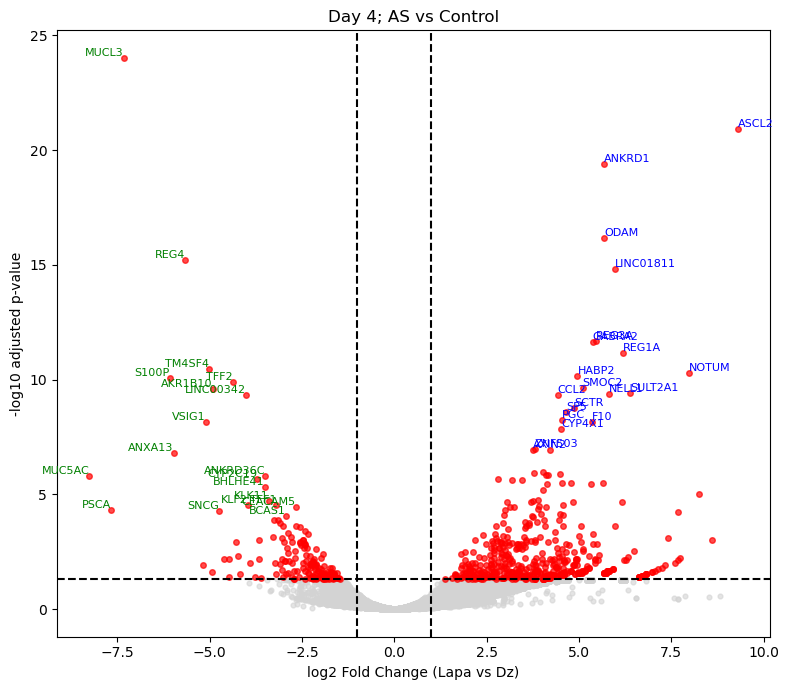

In [41]:
import numpy as np
import matplotlib.pyplot as plt

df = res.copy()
df = df.dropna(subset=["log2FoldChange", "padj"])
df["-log10padj"] = -np.log10(df["padj"])

# ----- define significance (optional) -----
sig = (df["padj"] < 0.05) & (df["log2FoldChange"].abs() > 1)

# ---- select top 20 up-regulated genes ----
top_up = (
    df[df["log2FoldChange"] > 0]
    .sort_values("padj")
    .head(20)
)

# ---- select top 20 down-regulated genes ----
top_down = (
    df[df["log2FoldChange"] < 0]
    .sort_values("padj")
    .head(20)
)

plt.figure(figsize=(8,7))

# ---- plot non-significant ----
plt.scatter(
    df.loc[~sig, "log2FoldChange"],
    df.loc[~sig, "-log10padj"],
    color="lightgray",
    alpha=0.6,
    s=12,
)

# ---- plot significant ----
plt.scatter(
    df.loc[sig, "log2FoldChange"],
    df.loc[sig, "-log10padj"],
    color="red",
    alpha=0.7,
    s=16,
)

# ---- threshold lines ----
plt.axhline(-np.log10(0.05), linestyle="--", color="black")
plt.axvline(1, linestyle="--", color="black")
plt.axvline(-1, linestyle="--", color="black")

# ---- label top up-regulated ----
for gene, row in top_up.iterrows():
    x, y = row["log2FoldChange"], row["-log10padj"]
    plt.text(
        x,
        y,
        gene,
        fontsize=8,
        color="blue",
        ha="left",
        va="bottom"
    )

# ---- label top down-regulated ----
for gene, row in top_down.iterrows():
    x, y = row["log2FoldChange"], row["-log10padj"]
    plt.text(
        x,
        y,
        gene,
        fontsize=8,
        color="green",
        ha="right",
        va="bottom"
    )

plt.xlabel("log2 Fold Change (Lapa vs Dz)")
plt.ylabel("-log10 adjusted p-value")
plt.title("Day 4; AS vs Control")
plt.tight_layout()
plt.show()


In [42]:
res.to_csv(
    "/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-output/d4_as_enterocytes_deseq2_results.csv",
    index=True
)